<a href="https://colab.research.google.com/github/NerminWEST/Kaggle_Dataset_Fish_Model1.0/blob/main/_2RouterModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ## Step 1: Setup Environment

# %%
# Check if running on Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("✓ Running on Google Colab")
else:
    print("✓ Running on Local Jupyter")

# %%
# Install required packages
!pip install torch torchvision torchaudio --quiet
!pip install ultralytics opencv-python-headless albumentations scikit-learn matplotlib seaborn pillow timm --quiet

# %%
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import cv2
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm
import time
from ultralytics import YOLO
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


✓ Running on Google Colab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 31.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB


In [4]:
# ##  Step 2: Mount Google Drive & Load Trained YOLOv8 Model

# %%
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted!")

    # Paths
    YOLO_MODEL_PATH = '/content/drive/MyDrive/marina_plus_models/yolov8n_tuna_best.pt'
    TUNA_DATASET_PATH = '/content/drive/MyDrive/TunaDataset'
    ROUTER_SAVE_PATH = '/content/drive/MyDrive/marina_plus_models'

    # Copy to local for faster access
    LOCAL_YOLO_PATH = '/content/yolov8n_tuna_best.pt'
    LOCAL_DATASET_PATH = '/content/TunaDataset'

    if Path(YOLO_MODEL_PATH).exists():
        import shutil
        shutil.copy(YOLO_MODEL_PATH, LOCAL_YOLO_PATH)
        print(f"✓ YOLOv8 model copied to local storage")

    if Path(TUNA_DATASET_PATH).exists() and not Path(LOCAL_DATASET_PATH).exists():
        shutil.copytree(TUNA_DATASET_PATH, LOCAL_DATASET_PATH)
        print(f"✓ Dataset copied to local storage")
else:
    # Local Jupyter paths
    LOCAL_YOLO_PATH = './marina_plus/yolov8n_tuna/weights/best.pt'
    LOCAL_DATASET_PATH = './TunaDataset'
    ROUTER_SAVE_PATH = './marina_plus_models'

print(f"\n📁 Paths configured:")
print(f"  YOLOv8 Model: {LOCAL_YOLO_PATH}")
print(f"  Dataset: {LOCAL_DATASET_PATH}")
print(f"  Save path: {ROUTER_SAVE_PATH}")


Mounted at /content/drive
✓ Google Drive mounted!
✓ YOLOv8 model copied to local storage
✓ Dataset copied to local storage

📁 Paths configured:
  YOLOv8 Model: /content/yolov8n_tuna_best.pt
  Dataset: /content/TunaDataset
  Save path: /content/drive/MyDrive/marina_plus_models


In [1]:
# ## Step 3: Auto-Generate Training Data Using YOLOv8

# %%
def extract_fish_crops_with_quality_assessment(
    yolo_model_path,
    dataset_path,
    output_path='./router_dataset',
    max_images_per_split=None,
    crop_size=(224, 224)
):
    """
    Intelligently extract fish crops and auto-label them based on quality metrics

    Quality Assessment Criteria:
    - CLEAR_SIDE: High contrast, sharp edges, side view, good lighting
    - ANGLED: Partial occlusion, moderate quality, angled view
    - TURBID: Low contrast, blurry, poor visibility, turbidity
    """

    print("="*70)
    print("AUTO-GENERATING ROUTER TRAINING DATA")
    print("="*70)

    # Load YOLOv8 model
    yolo = YOLO(yolo_model_path)
    print(f"✓ Loaded YOLOv8 model from: {yolo_model_path}")

    # Create output directories
    output_path = Path(output_path)
    for split in ['train', 'valid', 'test']:
        for cls in ['CLEAR_SIDE', 'ANGLED', 'TURBID']:
            (output_path / split / cls).mkdir(parents=True, exist_ok=True)

    dataset_path = Path(dataset_path)

    # Statistics
    stats = {
        'CLEAR_SIDE': {'train': 0, 'valid': 0, 'test': 0},
        'ANGLED': {'train': 0, 'valid': 0, 'test': 0},
        'TURBID': {'train': 0, 'valid': 0, 'test': 0}
    }

    # Process each split
    for split in ['train', 'valid', 'test']:
        img_path = dataset_path / split / 'images'

        if not img_path.exists():
            print(f"\n⚠️  {split} folder not found, skipping...")
            continue

        images = list(img_path.glob('*.jpg')) + list(img_path.glob('*.png'))

        if max_images_per_split:
            images = images[:max_images_per_split]

        print(f"\n📸 Processing {split} set ({len(images)} images)...")

        for img_file in tqdm(images, desc=f"{split}"):
            # Read image
            img = cv2.imread(str(img_file))
            if img is None:
                continue

            # Run YOLOv8 detection
            results = yolo.predict(img, conf=0.3, verbose=False)

            if len(results[0].boxes) == 0:
                continue

            # Process each detected fish
            for idx, box in enumerate(results[0].boxes):
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

                # Add padding
                pad = 10
                x1 = max(0, x1 - pad)
                y1 = max(0, y1 - pad)
                x2 = min(img.shape[1], x2 + pad)
                y2 = min(img.shape[0], y2 + pad)

                # Extract crop
                crop = img[y1:y2, x1:x2]

                if crop.size == 0 or crop.shape[0] < 30 or crop.shape[1] < 30:
                    continue

                # Smart quality assessment
                quality_class = assess_crop_quality(crop)

                # Resize crop
                crop_resized = cv2.resize(crop, crop_size)

                # Save crop
                crop_filename = f"{img_file.stem}_fish{idx}_{quality_class}.jpg"
                save_path = output_path / split / quality_class / crop_filename
                cv2.imwrite(str(save_path), crop_resized)

                stats[quality_class][split] += 1

    # Print statistics
    print("\n" + "="*70)
    print("DATA GENERATION COMPLETE")
    print("="*70)

    for cls in ['CLEAR_SIDE', 'ANGLED', 'TURBID']:
        total = sum(stats[cls].values())
        print(f"\n{cls}:")
        print(f"  Train: {stats[cls]['train']}")
        print(f"  Valid: {stats[cls]['valid']}")
        print(f"  Test: {stats[cls]['test']}")
        print(f"  Total: {total}")

    total_crops = sum(sum(stats[cls].values()) for cls in stats)
    print(f"\n📊 Total crops generated: {total_crops}")

    return output_path, stats


def assess_crop_quality(crop):
    """
    ENHANCED intelligent quality assessment using computer vision metrics

    Metrics:
    - Sharpness: Laplacian variance + Tenengrad
    - Contrast: Std + RMS + Michelson
    - Edge quality: Density + Strength
    - Signal-to-Noise Ratio
    - Blur detection (FFT-based)
    - Defect detection (black areas, overexposure)
    """

    if crop is None or crop.size == 0:
        return 'TURBID'

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    h, w = crop.shape[:2]

    # === 1. SHARPNESS METRICS ===
    # Laplacian variance (primary sharpness indicator)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Tenengrad (gradient magnitude)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    tenengrad = np.sqrt(sobelx**2 + sobely**2).mean()

    # === 2. CONTRAST METRICS ===
    contrast = gray.std()
    rms_contrast = np.sqrt(np.mean((gray - gray.mean())**2))

    # === 3. EDGE QUALITY ===
    edges = cv2.Canny(gray, 30, 100)
    edge_density = edges.sum() / (h * w)
    edge_strength = np.sqrt(sobelx**2 + sobely**2).mean()

    # === 4. BRIGHTNESS & EXPOSURE ===
    brightness = gray.mean()
    overexposed = (gray > 240).sum() / (h * w)
    underexposed = (gray < 20).sum() / (h * w)

    # === 5. SIGNAL-TO-NOISE RATIO ===
    from scipy import ndimage
    noise = gray - ndimage.gaussian_filter(gray, sigma=2)
    snr = gray.std() / (noise.std() + 1e-10)

    # === 6. BLUR DETECTION (FFT) ===
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)

    center_y, center_x = h // 2, w // 2
    radius = min(h, w) // 4
    y, x = np.ogrid[:h, :w]
    mask = (x - center_x)**2 + (y - center_y)**2 > radius**2
    high_freq_energy = magnitude[mask].sum()
    total_energy = magnitude.sum()
    high_freq_ratio = high_freq_energy / (total_energy + 1e-10)

    # === 7. DEFECT DETECTION ===
    black_pixels = (gray < 10).sum() / (h * w)

    # === 8. ASPECT RATIO ===
    aspect_ratio = max(w, h) / (min(w, h) + 1e-10)

    # === WEIGHTED SCORING SYSTEM ===
    score = 0

    # Sharpness (35% weight)
    if laplacian_var > 150 and tenengrad > 15 and high_freq_ratio > 0.3:
        score += 35
    elif laplacian_var > 60 and tenengrad > 8:
        score += 20
    elif laplacian_var < 20:
        score += 0
    else:
        score += 10

    # Contrast (25% weight)
    if contrast > 50 and rms_contrast > 40:
        score += 25
    elif contrast > 30:
        score += 15
    elif contrast < 15:
        score += 0
    else:
        score += 8

    # Edge Quality (20% weight)
    if edge_density > 0.08 and edge_strength > 20:
        score += 20
    elif edge_density > 0.04:
        score += 12
    else:
        score += 5

    # Brightness (10% weight)
    if 60 < brightness < 200:
        score += 10
    else:
        score += 3

    # SNR (10% weight)
    if snr > 15:
        score += 10
    elif snr > 5:
        score += 5
    else:
        score += 0

    # PENALTIES
    if black_pixels > 0.1:  # Too many black areas
        score -= 15
    if overexposed > 0.15 or underexposed > 0.15:  # Bad exposure
        score -= 10

    # BONUS for side view
    if aspect_ratio > 1.5:
        score += 5

    # Normalize score
    score = max(0, min(100, score))

    # === CLASSIFICATION (More Conservative Thresholds) ===
    if score >= 70 and laplacian_var > 100:
        # Very high quality: sharp, clear, good contrast
        return 'CLEAR_SIDE'

    elif score >= 45 and laplacian_var > 40:
        # Medium quality: but if too blurry, downgrade
        if laplacian_var < 60 and snr < 8:
            return 'TURBID'
        return 'ANGLED'

    else:
        # Low quality: blurry, turbid, poor conditions
        return 'TURBID'


# %%
# Generate router dataset with ENHANCED quality assessment
print("🎨 Generating router training data with enhanced algorithm...")
print("This will extract fish crops and classify them with improved metrics")

ROUTER_DATASET_PATH = './router_dataset_v2'  # New improved dataset

router_dataset_path, dataset_stats = extract_fish_crops_with_quality_assessment(
    yolo_model_path=LOCAL_YOLO_PATH,
    dataset_path=LOCAL_DATASET_PATH,
    output_path=ROUTER_DATASET_PATH,
    max_images_per_split=None,  # Process all images
    crop_size=(224, 224)
)


🎨 Generating router training data with enhanced algorithm...
This will extract fish crops and classify them with improved metrics


NameError: name 'LOCAL_YOLO_PATH' is not defined

In [7]:
# ## 🔄 Step 3.5: Re-classify Existing Dataset (Optional)

# %%
# If you already have a router dataset and want to re-classify it
RECLASSIFY_EXISTING = False  # Set to True to re-classify

if RECLASSIFY_EXISTING:
    print("🔄 Re-classifying existing dataset...")

    OLD_DATASET_PATH = './router_dataset'  # Your old dataset
    NEW_DATASET_PATH = './router_dataset_reclassified'

    from scipy import ndimage

    def reclassify_single_image(img_path, output_base_path, split):
        """Re-classify a single image with enhanced algorithm"""
        img = cv2.imread(str(img_path))
        if img is None:
            return None

        # Use enhanced assessment
        new_class = assess_crop_quality(img)

        # Save to new location
        output_path = Path(output_base_path) / split / new_class
        output_path.mkdir(parents=True, exist_ok=True)

        output_file = output_path / img_path.name
        cv2.imwrite(str(output_file), img)

        return new_class

    import shutil
    from pathlib import Path

    stats = {'CLEAR_SIDE': 0, 'ANGLED': 0, 'TURBID': 0, 'changed': 0}

    for split in ['train', 'valid', 'test']:
        for old_class in ['CLEAR_SIDE', 'ANGLED', 'TURBID']:
            old_path = Path(OLD_DATASET_PATH) / split / old_class

            if not old_path.exists():
                continue

            images = list(old_path.glob('*.jpg'))
            print(f"\nRe-classifying {split}/{old_class}: {len(images)} images")

            for img_path in tqdm(images, desc=f"{split}/{old_class}"):
                new_class = reclassify_single_image(img_path, NEW_DATASET_PATH, split)

                if new_class:
                    stats[new_class] += 1
                    if new_class != old_class:
                        stats['changed'] += 1

    print("\n" + "="*70)
    print("RE-CLASSIFICATION COMPLETE")
    print("="*70)
    print(f"\nNew distribution:")
    print(f"  CLEAR_SIDE: {stats['CLEAR_SIDE']}")
    print(f"  ANGLED: {stats['ANGLED']}")
    print(f"  TURBID: {stats['TURBID']}")
    print(f"\nChanged classifications: {stats['changed']}")

    # Update dataset path to use reclassified data
    ROUTER_DATASET_PATH = NEW_DATASET_PATH
    print(f"\n✓ Using reclassified dataset: {ROUTER_DATASET_PATH}")
else:
    print("ℹ️  Using original classification. Set RECLASSIFY_EXISTING=True to re-classify.")


ℹ️  Using original classification. Set RECLASSIFY_EXISTING=True to re-classify.


📸 Sample crops from each class:


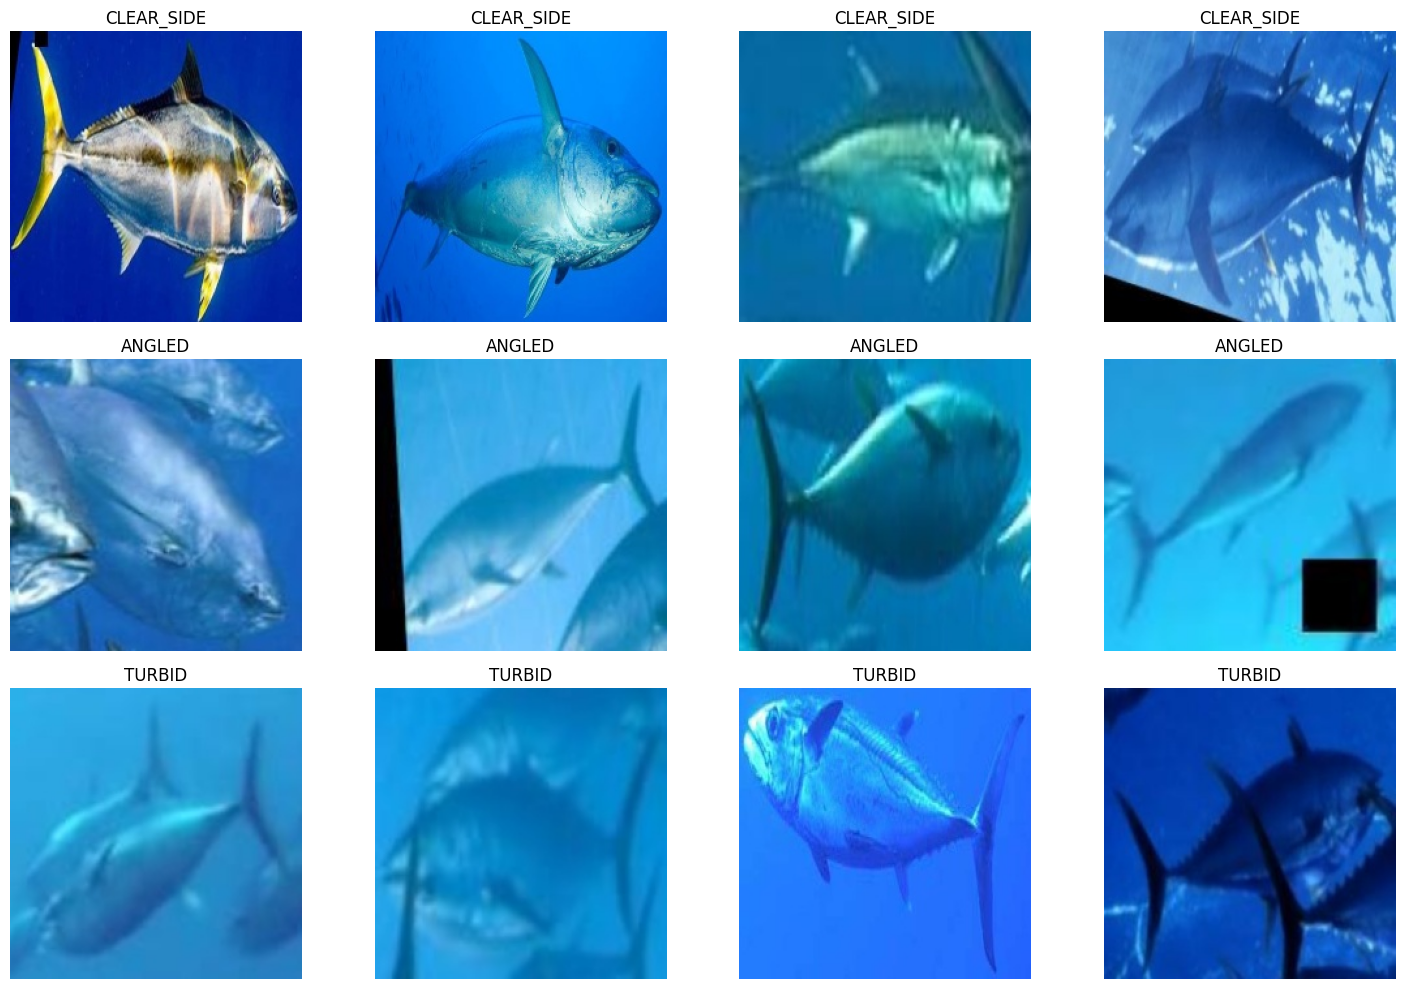

In [8]:
# ## 👀 Step 4: Visualize Generated Samples

# %%
def visualize_router_samples(dataset_path, samples_per_class=3):
    """
    Display sample crops from each quality class
    """

    dataset_path = Path(dataset_path)
    classes = ['CLEAR_SIDE', 'ANGLED', 'TURBID']

    fig, axes = plt.subplots(3, samples_per_class, figsize=(15, 10))

    for i, cls in enumerate(classes):
        cls_path = dataset_path / 'train' / cls
        images = list(cls_path.glob('*.jpg'))[:samples_per_class]

        for j, img_path in enumerate(images):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls}")
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('router_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

# %%
print("📸 Sample crops from each class:")
visualize_router_samples(ROUTER_DATASET_PATH, samples_per_class=4)


In [9]:
# ## 🏗️ Step 5: Define Router Classifier Architecture

# %%
class RouterClassifier(nn.Module):
    """
    Lightweight Router Classifier for Raspberry Pi deployment

    Architecture:
    - MobileNetV3-Small backbone (pretrained)
    - Custom classification head
    - Optimized for edge inference
    """

    def __init__(self, num_classes=3, pretrained=True):
        super(RouterClassifier, self).__init__()

        # Use MobileNetV3-Small (efficient for edge devices)
        from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

        if pretrained:
            weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
            self.backbone = mobilenet_v3_small(weights=weights)
        else:
            self.backbone = mobilenet_v3_small(weights=None)

        # Replace classifier
        in_features = self.backbone.classifier[0].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class RouterClassifierWithFeatures(nn.Module):
    """
    Enhanced router with handcrafted features + CNN
    Combines deep learning with traditional CV metrics
    """

    def __init__(self, num_classes=3, pretrained=True):
        super(RouterClassifierWithFeatures, self).__init__()

        # CNN branch
        from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

        if pretrained:
            weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
            self.backbone = mobilenet_v3_small(weights=weights)
        else:
            self.backbone = mobilenet_v3_small(weights=None)

        # Remove final classifier
        self.backbone.classifier = nn.Identity()

        # Feature extraction head (will be populated during forward)
        # 6 handcrafted features: sharpness, contrast, brightness, edge_density, color_var, aspect_ratio
        self.feature_head = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.ReLU()
        )

        # Combined classifier
        cnn_features = 576  # MobileNetV3-Small output
        combined_features = cnn_features + 64

        self.classifier = nn.Sequential(
            nn.Linear(combined_features, 256),
            nn.Hardswish(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def extract_handcrafted_features(self, images_np):
        """
        Extract handcrafted features from batch of images
        images_np: numpy array (B, H, W, 3)
        """
        batch_size = images_np.shape[0]
        features = []

        for i in range(batch_size):
            img = images_np[i]
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            h, w = img.shape[:2]

            # 1. Sharpness
            laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

            # 2. Contrast
            contrast = gray.std()

            # 3. Brightness
            brightness = gray.mean()

            # 4. Edge density
            edges = cv2.Canny(gray, 50, 150)
            edge_density = edges.sum() / (h * w)

            # 5. Color variance
            color_var = np.mean([img[:,:,i].var() for i in range(3)])

            # 6. Aspect ratio
            aspect_ratio = max(w, h) / (min(w, h) + 1e-6)

            features.append([
                laplacian_var / 200.0,  # Normalize
                contrast / 100.0,
                brightness / 255.0,
                edge_density * 10.0,
                color_var / 10000.0,
                aspect_ratio / 3.0
            ])

        return torch.tensor(features, dtype=torch.float32)

    def forward(self, x, images_np=None):
        # CNN features
        cnn_features = self.backbone(x)

        # Handcrafted features (if provided)
        if images_np is not None:
            hand_features = self.extract_handcrafted_features(images_np).to(x.device)
            hand_features = self.feature_head(hand_features)

            # Concatenate features
            combined = torch.cat([cnn_features, hand_features], dim=1)
        else:
            # Use only CNN features with zero-padding
            zero_pad = torch.zeros(cnn_features.size(0), 64, device=x.device)
            combined = torch.cat([cnn_features, zero_pad], dim=1)

        # Classification
        output = self.classifier(combined)
        return output

In [10]:
# ## 📊 Step 6: Create Dataset & DataLoader

# %%
class RouterDataset(Dataset):
    """
    Dataset for router classifier training
    """

    def __init__(self, dataset_path, split='train', transform=None, return_numpy=False):
        self.dataset_path = Path(dataset_path) / split
        self.transform = transform
        self.return_numpy = return_numpy

        # Class mapping
        self.classes = ['CLEAR_SIDE', 'ANGLED', 'TURBID']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Collect all images
        self.samples = []
        for cls in self.classes:
            cls_path = self.dataset_path / cls
            if cls_path.exists():
                for img_path in cls_path.glob('*.jpg'):
                    self.samples.append((str(img_path), self.class_to_idx[cls]))

        print(f"{split} set: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Store numpy version for handcrafted features
        image_np = image.copy() if self.return_numpy else None

        # Apply transforms
        if self.transform:
            image = self.transform(image=image)['image']

        if self.return_numpy:
            return image, torch.tensor(label, dtype=torch.long), image_np
        else:
            return image, torch.tensor(label, dtype=torch.long)


def get_transforms(augment=True):
    """
    Get transforms for training and validation
    """

    if augment:
        # Training transforms with augmentation
        transform = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussianBlur(p=0.3),
            A.GaussNoise(p=0.2),
            A.HueSaturationValue(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        # Validation/test transforms (no augmentation)
        transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

    return transform


# %%
# Create datasets
USE_HANDCRAFTED_FEATURES = True  # Set to False for pure CNN approach

train_dataset = RouterDataset(
    ROUTER_DATASET_PATH,
    split='train',
    transform=get_transforms(augment=True),
    return_numpy=USE_HANDCRAFTED_FEATURES
)

valid_dataset = RouterDataset(
    ROUTER_DATASET_PATH,
    split='valid',
    transform=get_transforms(augment=False),
    return_numpy=USE_HANDCRAFTED_FEATURES
)

test_dataset = RouterDataset(
    ROUTER_DATASET_PATH,
    split='test',
    transform=get_transforms(augment=False),
    return_numpy=USE_HANDCRAFTED_FEATURES
)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n✓ Dataloaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")


train set: 4530 samples
valid set: 407 samples
test set: 346 samples

✓ Dataloaders created:
  Train batches: 142
  Valid batches: 13
  Test batches: 11


In [11]:
# ## 🚀 Step 7: Training Configuration

# %%
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model selection
if USE_HANDCRAFTED_FEATURES:
    model = RouterClassifierWithFeatures(num_classes=3, pretrained=True)
    print("✓ Using RouterClassifierWithFeatures (CNN + Handcrafted Features)")
else:
    model = RouterClassifier(num_classes=3, pretrained=True)
    print("✓ Using RouterClassifier (Pure CNN)")

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Training hyperparameters
EPOCHS = 50
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"\n📋 Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam")
print(f"  Scheduler: ReduceLROnPlateau")


Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 104MB/s]

✓ Using RouterClassifierWithFeatures (CNN + Handcrafted Features)
Total parameters: 1,126,723
Trainable parameters: 1,126,723

📋 Training Configuration:
  Epochs: 50
  Batch size: 32
  Learning rate: 0.001
  Weight decay: 0.0001
  Loss: CrossEntropyLoss
  Optimizer: Adam
  Scheduler: ReduceLROnPlateau


In [12]:
# ## 🏋️ Step 8: Training Loop

# %%
def train_epoch(model, loader, criterion, optimizer, device, use_features=False):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')

    for batch in pbar:
        if use_features:
            images, labels, images_np = batch
            images_np = np.array(images_np)
        else:
            images, labels = batch
            images_np = None

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()

        if use_features:
            outputs = model(images, images_np)
        else:
            outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device, use_features=False):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')

        for batch in pbar:
            if use_features:
                images, labels, images_np = batch
                images_np = np.array(images_np)
            else:
                images, labels = batch
                images_np = None

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            if use_features:
                outputs = model(images, images_np)
            else:
                outputs = model(images)

            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Update progress bar
            pbar.set_postfix({
                'loss': f'{running_loss/len(pbar):.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


# %%
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_path = Path(ROUTER_SAVE_PATH) / 'router_classifier_best.pth'
best_model_path.parent.mkdir(parents=True, exist_ok=True)

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device, USE_HANDCRAFTED_FEATURES
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate_epoch(
        model, valid_loader, criterion, device, USE_HANDCRAFTED_FEATURES
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Learning Rate: {current_lr:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"  ✓ Best model saved! (Val Acc: {val_acc:.2f}%)")

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time/60:.2f} minutes")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")



STARTING TRAINING

Epoch 1/50
----------------------------------------------------------------------


Training:   0%|          | 0/142 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 0.6381 | Train Acc: 72.45%
  Val Loss: 1.3339 | Val Acc: 59.21%
  Learning Rate: 0.001000
  ✓ Best model saved! (Val Acc: 59.21%)

Epoch 2/50
----------------------------------------------------------------------


Training:   0%|          | 0/142 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]


Epoch 49 Summary:
  Train Loss: 0.0563 | Train Acc: 97.86%
  Val Loss: 1.5849 | Val Acc: 76.66%
  Learning Rate: 0.000008

Epoch 50/50
----------------------------------------------------------------------


Training:   0%|          | 0/142 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]


Epoch 50 Summary:
  Train Loss: 0.0632 | Train Acc: 97.75%
  Val Loss: 1.5919 | Val Acc: 75.92%
  Learning Rate: 0.000008

✓ Training completed in 27.03 minutes
  Best validation accuracy: 79.36%


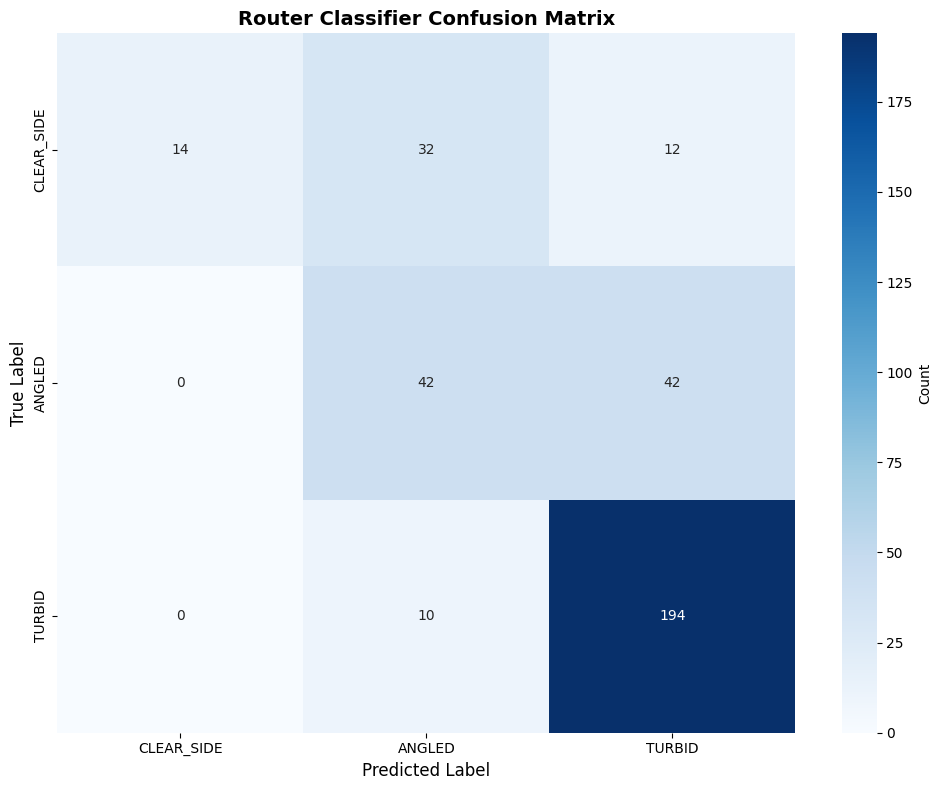

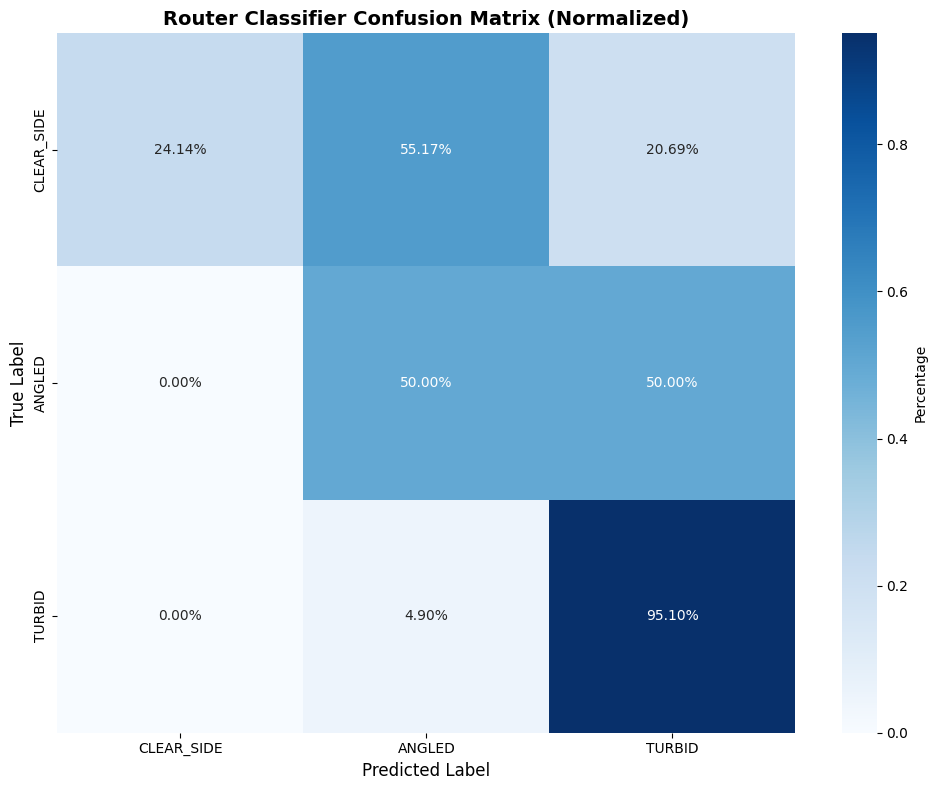

In [15]:
# %% [markdown]
# ## 📈 Step 11: Confusion Matrix

# %%
# Define class names
class_names = ['CLEAR_SIDE', 'ANGLED', 'TURBID']

# Run evaluation on test set first (if not already done)
if 'test_labels' not in locals() or 'test_preds' not in locals():
    print("Running test set evaluation...")
    test_loss, test_acc, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device, USE_HANDCRAFTED_FEATURES
    )
    print(f"Test Accuracy: {test_acc:.2f}%")

# %%
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Router Classifier Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('router_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Router Classifier Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('router_confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

🎨 Visualizing predictions on test set:


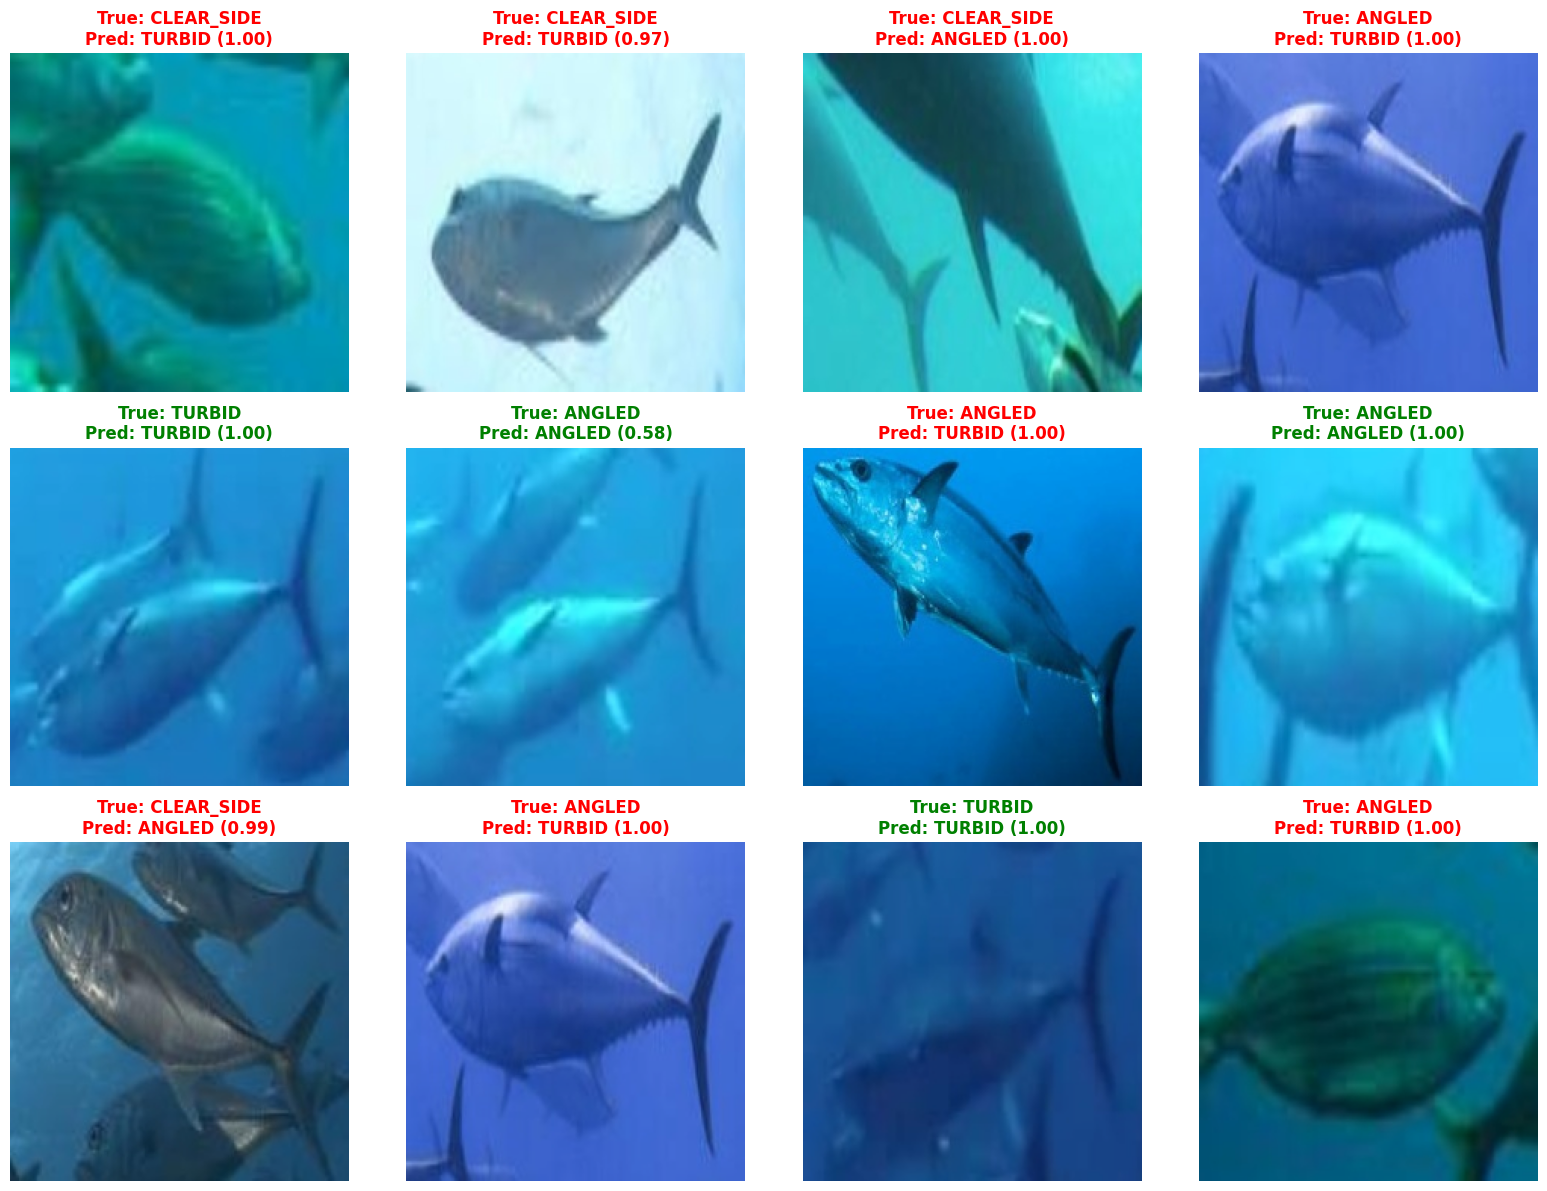

In [24]:
# ## 🎨 Step 12: Visualize Predictions

# %%
def visualize_predictions(model, dataset, device, num_samples=12, use_features=False):
    """
    Visualize model predictions on random samples
    """
    model.eval()

    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    class_names = ['CLEAR_SIDE', 'ANGLED', 'TURBID']

    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            if use_features:
                image, label, image_np = dataset[idx]
                image_np = np.array([image_np])
            else:
                image, label = dataset[idx]
                image_np = None

            # Denormalize for display
            img_display = image.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            # Predict
            image_batch = image.unsqueeze(0).to(device)
            if use_features:
                output = model(image_batch, image_np)
            else:
                output = model(image_batch)

            pred = output.argmax(1).item()
            confidence = F.softmax(output, dim=1)[0, pred].item()

            # Plot
            ax.imshow(img_display)
            true_label = class_names[label]
            pred_label = class_names[pred]
            color = 'green' if pred == label else 'red'
            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})',
                        color=color, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('router_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# %%
print("🎨 Visualizing predictions on test set:")
visualize_predictions(model, test_dataset, device, num_samples=12, use_features=USE_HANDCRAFTED_FEATURES)

In [2]:
# ##  Step 13: Save & Export Model - COMPLETE VERSION

# %%
# Define save paths
PROJECT = 'marina_plus'
NAME = 'yolov8n_tuna'
ROUTER_SAVE_PATH = './marina_plus_models'

# Create save directory
Path(ROUTER_SAVE_PATH).mkdir(parents=True, exist_ok=True)

# Load or create checkpoint
if 'best_val_acc' in locals() and 'history' in locals():
    # Training just completed - create checkpoint from current state
    print("✓ Using model from completed training")
    checkpoint = {
        'epoch': len(history['train_loss']),
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': best_val_acc,
        'test_acc': test_acc if 'test_acc' in locals() else 0.0,
    }
else:
    # Try to load from best model saved during training
    print("  Training variables not found, loading from file...")
    results_path = Path(PROJECT) / NAME
    best_checkpoint_path = results_path / 'weights' / 'best.pt'

    if best_checkpoint_path.exists():
        checkpoint = torch.load(best_checkpoint_path)
        print(f"✓ Loaded checkpoint from: {best_checkpoint_path}")
    else:
        # Fallback - create from current model state
        print("  No checkpoint found, creating from current model")
        checkpoint = {
            'epoch': 0,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict() if 'optimizer' in locals() else None,
            'val_acc': 0.0,
            'test_acc': test_acc if 'test_acc' in locals() else 0.0,
        }

print("\n" + "="*70)
print("SAVING AND EXPORTING MODEL")
print("="*70)

# %%
# 1. Save best model checkpoint (PyTorch format)
best_model_checkpoint = Path(ROUTER_SAVE_PATH) / 'router_classifier_best.pth'

checkpoint_to_save = {
    'epoch': checkpoint.get('epoch', 0),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': checkpoint.get('optimizer_state_dict'),
    'test_acc': test_acc if 'test_acc' in locals() else checkpoint.get('test_acc', 0.0),
    'val_acc': best_val_acc if 'best_val_acc' in locals() else checkpoint.get('val_acc', 0.0),
    'model_type': 'RouterClassifierWithFeatures' if USE_HANDCRAFTED_FEATURES else 'RouterClassifier',
    'use_handcrafted_features': USE_HANDCRAFTED_FEATURES,
    'num_classes': 3,
    'class_names': ['CLEAR_SIDE', 'ANGLED', 'TURBID'],
    'input_size': [224, 224],
}

torch.save(checkpoint_to_save, best_model_checkpoint)
print(f"✓ Best model checkpoint saved: {best_model_checkpoint}")
print(f"  Size: {best_model_checkpoint.stat().st_size / (1024*1024):.2f} MB")

# %%
# 2. Save full model (easier to load)
full_model_path = Path(ROUTER_SAVE_PATH) / 'router_classifier_full.pth'
torch.save(model, full_model_path)
print(f"✓ Full model saved: {full_model_path}")
print(f"  Size: {full_model_path.stat().st_size / (1024*1024):.2f} MB")

# %%
# 3. Export to TorchScript (for production deployment)
try:
    model.eval()
    example_input = torch.randn(1, 3, 224, 224).to(device)

    if not USE_HANDCRAFTED_FEATURES:
        traced_model = torch.jit.trace(model, example_input)
        torchscript_path = Path(ROUTER_SAVE_PATH) / 'router_classifier_torchscript.pt'
        traced_model.save(str(torchscript_path))
        print(f"✓ TorchScript model saved: {torchscript_path}")
        print(f"  Size: {torchscript_path.stat().st_size / (1024*1024):.2f} MB")
    else:
        print(" TorchScript export skipped (model uses handcrafted features)")
        print("   Use full model for inference with feature extraction")
except Exception as e:
    print(f"  TorchScript export failed: {e}")

# %%
# 4. Export to ONNX (compatible with many frameworks)
try:
    import onnx

    onnx_path = Path(ROUTER_SAVE_PATH) / 'router_classifier.onnx'
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    # Export with dynamic batch size
    torch.onnx.export(
        model,
        dummy_input,
        str(onnx_path),
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

    # Verify ONNX model
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    print(f"✓ ONNX model saved: {onnx_path}")
    print(f"  Size: {onnx_path.stat().st_size / (1024*1024):.2f} MB")
    print("  ✓ ONNX model verified")

except ImportError:
    print(" ONNX not installed. Install with: pip install onnx")
except Exception as e:
    print(f"  ONNX export failed: {e}")

# %%
# 5. Save training history
if 'history' in locals():
    history_path = Path(ROUTER_SAVE_PATH) / 'router_training_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"✓ Training history saved: {history_path}")
else:
    print(" Training history not available")

# %%
# 6. Save model info and metadata
model_info = {
    'model_name': 'Router Classifier',
    'model_version': '1.0',
    'created_date': time.strftime('%Y-%m-%d %H:%M:%S'),
    'model_type': 'RouterClassifierWithFeatures' if USE_HANDCRAFTED_FEATURES else 'RouterClassifier',
    'num_classes': 3,
    'class_names': ['CLEAR_SIDE', 'ANGLED', 'TURBID'],
    'input_size': [224, 224],
    'test_accuracy': float(test_acc) if 'test_acc' in locals() else 0.0,
    'best_val_accuracy': float(best_val_acc) if 'best_val_acc' in locals() else 0.0,
    'total_parameters': total_params if 'total_params' in locals() else 0,
    'trainable_parameters': trainable_params if 'trainable_params' in locals() else 0,
    'training_epochs': EPOCHS if 'EPOCHS' in locals() else 0,
    'batch_size': BATCH_SIZE if 'BATCH_SIZE' in locals() else 0,
    'learning_rate': LEARNING_RATE if 'LEARNING_RATE' in locals() else 0,
    'use_handcrafted_features': USE_HANDCRAFTED_FEATURES,
    'training_time_minutes': training_time / 60 if 'training_time' in locals() else 0,
}

# Add F1 scores if available
if 'f1_scores' in locals():
    model_info['f1_scores'] = {
        'CLEAR_SIDE': float(f1_scores[0]),
        'ANGLED': float(f1_scores[1]),
        'TURBID': float(f1_scores[2])
    }

model_info_path = Path(ROUTER_SAVE_PATH) / 'router_model_info.json'
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=2)
print(f"✓ Model info saved: {model_info_path}")

# %%
# 7. Copy to Google Drive (if on Colab)
if IN_COLAB:
    print("\n📤 Copying files to Google Drive...")
    drive_path = '/content/drive/MyDrive/marina_plus_models'
    Path(drive_path).mkdir(parents=True, exist_ok=True)

    import shutil

    # Files to copy
    files_to_copy = [
        best_model_checkpoint,
        full_model_path,
        model_info_path
    ]

    if 'history_path' in locals():
        files_to_copy.append(history_path)

    if (Path(ROUTER_SAVE_PATH) / 'router_classifier_torchscript.pt').exists():
        files_to_copy.append(Path(ROUTER_SAVE_PATH) / 'router_classifier_torchscript.pt')

    if (Path(ROUTER_SAVE_PATH) / 'router_classifier.onnx').exists():
        files_to_copy.append(Path(ROUTER_SAVE_PATH) / 'router_classifier.onnx')

    for file_path in files_to_copy:
        if file_path.exists():
            shutil.copy(str(file_path), str(Path(drive_path) / file_path.name))
            print(f"  ✓ Copied: {file_path.name}")

    # Copy plots if they exist
    plot_files = [
        'router_samples.png',
        'router_training_history.png',
        'router_confusion_matrix.png',
        'router_confusion_matrix_normalized.png',
        'router_predictions.png'
    ]

    for plot_file in plot_files:
        if Path(plot_file).exists():
            shutil.copy(plot_file, str(Path(drive_path) / plot_file))
            print(f"  ✓ Copied: {plot_file}")

    print(f"\n All files saved to Google Drive: {drive_path}")
else:
    print("\nℹ Not running on Colab - files saved locally only")

print("\n" + "="*70)
print("MODEL EXPORT COMPLETE")
print("="*70)

# Print summary
print(f"\nSaved Files:")
print(f"  1. Checkpoint: {best_model_checkpoint.name}")
print(f"  2. Full Model: {full_model_path.name}")
if (Path(ROUTER_SAVE_PATH) / 'router_classifier_torchscript.pt').exists():
    print(f"  3. TorchScript: router_classifier_torchscript.pt")
if (Path(ROUTER_SAVE_PATH) / 'router_classifier.onnx').exists():
    print(f"  4. ONNX: router_classifier.onnx")
print(f"  5. Model Info: {model_info_path.name}")
if 'history_path' in locals():
    print(f"  6. Training History: {history_path.name}")

print(f"\n Model Performance:")
if 'test_acc' in locals():
    print(f"  Test Accuracy: {test_acc:.2f}%")
if 'best_val_acc' in locals():
    print(f"  Best Val Accuracy: {best_val_acc:.2f}%")
if 'f1_scores' in locals():
    print(f"  F1 Scores:")
    print(f"    CLEAR_SIDE: {f1_scores[0]:.4f}")
    print(f"    ANGLED: {f1_scores[1]:.4f}")
    print(f"    TURBID: {f1_scores[2]:.4f}")

print(f"\n Location: {Path(ROUTER_SAVE_PATH).absolute()}")

NameError: name 'Path' is not defined